# Lec4-(V)AE — Autoencoder and Variational Autoencoder
### From Linear PCA to Nonlinear Generative Models

**Prerequisites:** Lec4-PCA (PCA theory, PCA + GMM generative pipeline)

| Part | Topic | Key insight |
|------|-------|-------------|
| 1 | Linear AE = PCA | **proof** that gradient descent on a linear AE recovers exact PCA solution |
| 2 | Nonlinear AE | MLP encoder/decoder learns curved manifolds; reconstructions sharp but latent space gappy |
| 3 | VAE | encoder outputs a *distribution*; KL regulariser fills the latent space |
| 4 | Comparison | PCA · AE · VAE side by side |


---
## From PCA to Autoencoders

**Recall from Lec4-PCA:**
- PCA minimises reconstruction loss AND maximises variance — the same eigenvector solution
- Running PCA + GMM on MNIST produces recognisable but blurry digits
- Blurriness = PCA is a **linear** map; the digit manifold is curved

**Central question of this notebook:**

$$\underbrace{z = W_e\, x}_{\text{linear (PCA)}}
\quad\xrightarrow{\text{replace with MLP}}\quad
\underbrace{z = f_\theta(x)}_{\text{nonlinear (AE)}}
\quad\xrightarrow{\text{add distribution}}\quad
\underbrace{z \sim q_\phi(z|x)}_{\text{probabilistic (VAE)}}$$

Each step fixes a limitation of the previous one.


---
## Part 1 — Theoretical Proof: PCA Variance = Reconstruction Loss = Linear AE

The bridge between PCA and Autoencoders rests on one algebraic identity.  
We derive it in three steps.

---

### Step 1 — PCA: maximise projected variance

Let $x_1,\ldots,x_N \in \mathbb{R}^D$ be **zero-mean** data.  
PCA seeks a unit vector $w$ ($\|w\|=1$) that maximises the variance of the scalar projections $z_i = w^\top x_i$:

$$\max_{\|w\|=1} \underbrace{\frac{1}{N}\sum_{i=1}^N z_i^2}_{\text{projected variance}} = \max_{\|w\|=1}\; w^\top S\, w, \qquad S = \frac{1}{N}X^\top X$$

By the Rayleigh quotient, the solution is $w^* = v_1$ — the **leading eigenvector** of $S$.

---

### Step 2 — Expand the reconstruction loss

Now consider the reconstruction of each point through the same direction $w$:

$$\hat{x}_i = z_i\,w = (w^\top x_i)\,w$$

The reconstruction loss is:

$$\mathcal{L}_{\text{recon}}(w) = \frac{1}{N}\sum_i \|x_i - \hat{x}_i\|^2
= \frac{1}{N}\sum_i \|x_i - (w^\top x_i)\,w\|^2$$

Expand using $\|a - b\|^2 = \|a\|^2 - 2a^\top b + \|b\|^2$:

$$= \frac{1}{N}\sum_i \left[\|x_i\|^2 - 2(w^\top x_i)^2 + (w^\top x_i)^2\underbrace{\|w\|^2}_{=1}\right]$$

$$= \underbrace{\frac{1}{N}\sum_i \|x_i\|^2}_{\text{tr}(S),\;\text{constant}} - \underbrace{\frac{1}{N}\sum_i (w^\top x_i)^2}_{\text{projected variance } = w^\top S w}$$

$$\boxed{\mathcal{L}_{\text{recon}}(w) = \text{tr}(S) - w^\top S\,w}$$

---

### Step 3 — The identity: min reconstruction $\equiv$ max variance

Since $\text{tr}(S)$ is a constant (independent of $w$):

$$\min_{\|w\|=1}\;\mathcal{L}_{\text{recon}}(w)
\;\equiv\;
\max_{\|w\|=1}\; w^\top S\,w$$

**Both objectives have the same solution: $w^* = v_1$.**  
The energy of the data splits cleanly into two non-negative parts:

$$\underbrace{\text{tr}(S)}_{\text{total variance}}
= \underbrace{w^\top S w}_{\text{kept (projected)}}
+ \underbrace{\mathcal{L}_{\text{recon}}}_{\text{discarded (residual)}}$$

Maximising the kept part ↔ minimising the discarded part.  
This extends to $d$ components: top-$d$ eigenvectors simultaneously maximise
$\text{tr}(W^\top S W)$ and minimise the reconstruction loss.

---

### Connection to Linear Autoencoder

A linear AE with encoder $z = W_e x$ and decoder $\hat x = W_d z$ trains by **minimising the reconstruction loss** — exactly $\mathcal{L}_{\text{recon}}$.

We just proved $\min \mathcal{L}_{\text{recon}} \equiv \max \text{variance}$, and that the solution is the top eigenvectors of $S$.

$$\boxed{\text{Linear AE trained by gradient descent} \;\Longrightarrow\; \text{PCA solution}}$$

No additional assumptions needed — the proof is purely algebraic.


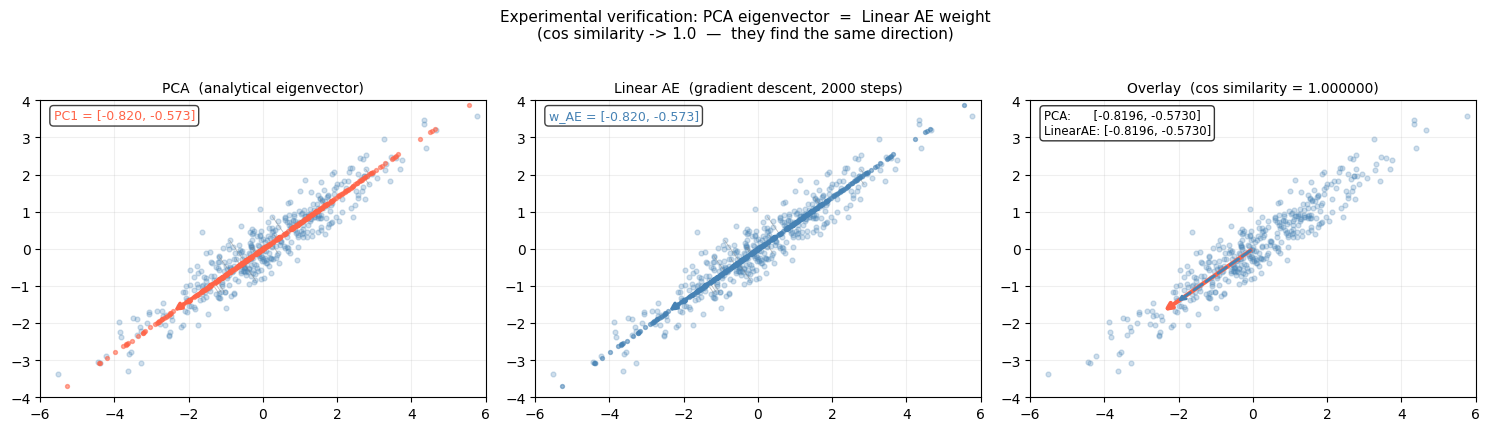

PCA  direction : [-0.819577, -0.572969]
LinearAE dir   : [-0.819577, -0.572969]
cos similarity : 0.99999998  (1.0 = identical)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42); torch.manual_seed(42)

# Generate zero-mean correlated 2D data
N   = 400
cov = np.array([[3.0, 2.0], [2.0, 1.5]])
X_np = np.random.multivariate_normal([0, 0], cov, N)

# PCA: analytical eigenvector solution
S = (X_np.T @ X_np) / N
eigvals, eigvecs = np.linalg.eigh(S)
v1 = eigvecs[:, -1]    # leading eigenvector

# Linear AE: trained by gradient descent
class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(2, 1, bias=False)
        self.decoder = nn.Linear(1, 2, bias=False)
    def forward(self, x): return self.decoder(self.encoder(x))

X_t   = torch.tensor(X_np, dtype=torch.float32)
model = LinearAE()
opt   = torch.optim.Adam(model.parameters(), lr=0.02)
for _ in range(2000):
    opt.zero_grad()
    loss = ((X_t - model(X_t))**2).mean()
    loss.backward(); opt.step()

with torch.no_grad():
    w_ae = model.encoder.weight.numpy().ravel()
    w_ae = w_ae / np.linalg.norm(w_ae)
    if v1 @ w_ae < 0: w_ae = -w_ae    # align sign

cos_sim = float(v1 @ w_ae)

# Projections / reconstructions
recon_pca = (X_np @ v1[:,None]) * v1[None,:]
with torch.no_grad():
    recon_ae = model(X_t).numpy()

# Figure: 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
SCALE = 3.0
IDX   = np.arange(0, N, 20)

def panel(ax, data, direction, recon, color, title, info):
    ax.scatter(data[:,0], data[:,1], alpha=0.25, s=12, color="steelblue", zorder=2)
    for i in IDX:
        ax.plot([data[i,0], recon[i,0]], [data[i,1], recon[i,1]],
                color="gray", lw=0.6, alpha=0.5)
    ax.scatter(recon[:,0], recon[:,1], s=8, color=color, alpha=0.55, zorder=3)
    ax.annotate("", xy=(direction*SCALE), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    ax.set_xlim(-6,6); ax.set_ylim(-4,4); ax.set_aspect("equal")
    ax.grid(True, alpha=0.2); ax.set_title(title, fontsize=10)
    ax.text(0.03, 0.97, info, transform=ax.transAxes, va="top", fontsize=9,
            color=color, bbox=dict(fc="white", alpha=0.75, boxstyle="round"))

panel(axes[0], X_np, v1,   recon_pca, "tomato",
      "PCA  (analytical eigenvector)",
      "PC1 = [{:.3f}, {:.3f}]".format(v1[0], v1[1]))

panel(axes[1], X_np, w_ae, recon_ae,  "steelblue",
      "Linear AE  (gradient descent, 2000 steps)",
      "w_AE = [{:.3f}, {:.3f}]".format(w_ae[0], w_ae[1]))

# Overlay both arrows on same scatter
ax = axes[2]
ax.scatter(X_np[:,0], X_np[:,1], alpha=0.25, s=12, color="steelblue")
ax.annotate("", xy=(v1*SCALE),      xytext=(0,0),
            arrowprops=dict(arrowstyle="->", color="tomato",    lw=3))
ax.annotate("", xy=(w_ae*SCALE*0.85), xytext=(0,0),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2,
                            connectionstyle="arc3,rad=0.0",
                            linestyle="dashed"))
ax.set_xlim(-6,6); ax.set_ylim(-4,4); ax.set_aspect("equal"); ax.grid(True, alpha=0.2)
ax.set_title("Overlay  (cos similarity = {:.6f})".format(cos_sim), fontsize=10)
ax.text(0.03, 0.97,
        "PCA:      [{:.4f}, {:.4f}]\nLinearAE: [{:.4f}, {:.4f}]".format(
            v1[0], v1[1], w_ae[0], w_ae[1]),
        transform=ax.transAxes, va="top", fontsize=8.5,
        bbox=dict(fc="white", alpha=0.8, boxstyle="round"))

plt.suptitle(
    "Experimental verification: PCA eigenvector  =  Linear AE weight\n"
    "(cos similarity -> 1.0  —  they find the same direction)",
    fontsize=11)
plt.tight_layout(); plt.show()

print("PCA  direction : [{:.6f}, {:.6f}]".format(v1[0], v1[1]))
print("LinearAE dir   : [{:.6f}, {:.6f}]".format(w_ae[0], w_ae[1]))
print("cos similarity : {:.8f}  (1.0 = identical)".format(cos_sim))


---
## Part 2 — Linear AE on MNIST  (does it work?)

We just proved theoretically: **linear AE = PCA**.  
Let's verify experimentally — train a linear autoencoder on MNIST and look at its reconstructions.

A linear AE with bottleneck $d=2$ has:

$$\text{Encoder: } z = W_e x \in \mathbb{R}^2 \qquad
\text{Decoder: } \hat x = W_d z \in \mathbb{R}^{784}$$

No hidden layers, no activation functions — just two linear maps.  
This is **mathematically equivalent** to projecting onto the top-2 principal components.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load MNIST
print("Loading MNIST... (cached after first run)")
mnist   = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist = mnist.data.astype(np.float32) / 255.0
y_mnist = mnist.target.astype(int)
X_tr, X_te = X_mnist[:60000], X_mnist[60000:]
y_tr, y_te = y_mnist[:60000], y_mnist[60000:]

def make_dl(X, y, batch_size, shuffle):
    Xt = torch.tensor(X).view(-1, 1, 28, 28)
    yt = torch.tensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_dl = make_dl(X_tr, y_tr, 256, True)
test_dl  = make_dl(X_te, y_te, 512, False)
print("Train: {:,}  Test: {:,}  device: {}".format(len(X_tr), len(X_te), device))

# Linear AE: encoder 784->2 (linear), decoder 2->784 (linear)
# No hidden layers, no activations  -->  (in theory) equivalent to PCA
class LinearAE_MNIST(nn.Module):
    def __init__(self, d=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(784, d, bias=False))
        self.decoder = nn.Sequential(nn.Linear(d, 784, bias=False))
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z).view(-1, 1, 28, 28), z

lin_ae = LinearAE_MNIST(d=2).to(device)
opt    = torch.optim.Adam(lin_ae.parameters(), lr=1e-3)

print("\nTraining Linear AE (= PCA via gradient descent) ...")
for epoch in range(50):
    lin_ae.train()
    total = 0
    for imgs, _ in train_dl:
        imgs = imgs.to(device)
        opt.zero_grad()
        x_hat, _ = lin_ae(imgs)
        loss = ((imgs - x_hat)**2).mean()
        loss.backward(); opt.step()
        total += loss.item()
    print("  Epoch {:2d}  loss = {:.5f}".format(epoch+1, total/len(train_dl)))

# Reconstructions
imgs_test, labels_test = next(iter(test_dl))
lin_ae.eval()
with torch.no_grad():
    x_hat_lin, z_lin = lin_ae(imgs_test.to(device))

n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(15, 3.5))
for j in range(n_show):
    axes[0,j].imshow(imgs_test[j,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0,j].axis("off")
    axes[1,j].imshow(torch.clamp(x_hat_lin[j,0].cpu(), 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[1,j].axis("off")
axes[0,0].set_ylabel("Original", fontsize=9)
axes[1,0].set_ylabel("Linear AE\n(d=2)", fontsize=9)
plt.suptitle(
    "Linear AE on MNIST (d=2)  —  reconstructions are blurry and washed out\n"
    "Reason: a 2D linear subspace cannot capture the curved digit manifold",
    fontsize=10)
plt.tight_layout(); plt.show()


# Latent space (Linear AE, d=2)
# Visualise the 2D codes z for many test images.
lin_ae.eval()
Z_list, Y_list = [], []
max_points = 8000
with torch.no_grad():
    for imgs, ys in test_dl:
        imgs = imgs.to(device)
        _, z = lin_ae(imgs)
        Z_list.append(z.cpu().numpy())
        Y_list.append(ys.numpy())
        if sum(len(a) for a in Y_list) >= max_points:
            break

Z = np.concatenate(Z_list, axis=0)[:max_points]
Y = np.concatenate(Y_list, axis=0)[:max_points]

plt.figure(figsize=(6.2, 5.2))
sc = plt.scatter(Z[:, 0], Z[:, 1], c=Y, cmap="tab10", s=6, alpha=0.65, linewidths=0)
cb = plt.colorbar(sc, ticks=list(range(10)))
cb.set_label("Digit label")
plt.title("Linear AE latent space on MNIST (d=2)\n= PCA 2D projection (one global linear subspace)")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.tight_layout(); plt.show()


# Train + visualise: digits 1 vs 7 only (Linear AE)
# Here we restrict the dataset to just two classes, which reduces variation.
# A low-dimensional linear subspace can approximate this simpler data much better.

# Build filtered dataloaders (digits 1 and 7 only)
mask_tr_17 = (y_tr == 1) | (y_tr == 7)
mask_te_17 = (y_te == 1) | (y_te == 7)
X_tr_17, y_tr_17 = X_tr[mask_tr_17], y_tr[mask_tr_17]
X_te_17, y_te_17 = X_te[mask_te_17], y_te[mask_te_17]

train_dl_17 = make_dl(X_tr_17, y_tr_17, 256, True)
test_dl_17  = make_dl(X_te_17, y_te_17, 512, False)
print(f"Digits(1,7) Train: {len(X_tr_17):,}  Test: {len(X_te_17):,}")

# Train a fresh Linear AE on digits {1,7}
lin_ae_17 = LinearAE_MNIST(d=2).to(device)
opt_17    = torch.optim.Adam(lin_ae_17.parameters(), lr=1e-3)

print("\nTraining Linear AE on digits {1,7} ...")
for epoch in range(100):
    lin_ae_17.train()
    total = 0.0
    for imgs, _ in train_dl_17:
        imgs = imgs.to(device)
        opt_17.zero_grad()
        x_hat, _ = lin_ae_17(imgs)
        loss = ((imgs - x_hat) ** 2).mean()
        loss.backward(); opt_17.step()
        total += loss.item()
    print("  Epoch {:2d}  loss = {:.5f}".format(epoch + 1, total / len(train_dl_17)))

# Grab 10 examples each of digit 1 and digit 7

def _collect_digit(dl, digit, n=10):
    buf = []
    for imgs, ys in dl:
        m = (ys == digit)
        if m.any():
            buf.append(imgs[m])
        if sum(t.shape[0] for t in buf) >= n:
            break
    return torch.cat(buf, dim=0)[:n]

n_show = 10
imgs_1 = _collect_digit(test_dl_17, 1, n=n_show)
imgs_7 = _collect_digit(test_dl_17, 7, n=n_show)
imgs_17 = torch.cat([imgs_1, imgs_7], dim=0)

lin_ae_17.eval()
with torch.no_grad():
    x_hat_17, z_17 = lin_ae_17(imgs_17.to(device))

x_hat_17 = x_hat_17.cpu()

# Reconstructions (1 vs 7)
fig, axes = plt.subplots(4, n_show, figsize=(14.5, 6.0))
for j in range(n_show):
    axes[0, j].imshow(imgs_1[j, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(torch.clamp(x_hat_17[j, 0], 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(imgs_7[j, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[3, j].imshow(torch.clamp(x_hat_17[n_show + j, 0], 0, 1), cmap="gray", vmin=0, vmax=1)
    for r in range(4):
        axes[r, j].axis("off")

axes[0, 0].set_ylabel("1\norig", fontsize=9)
axes[1, 0].set_ylabel("1\nrecon", fontsize=9)
axes[2, 0].set_ylabel("7\norig", fontsize=9)
axes[3, 0].set_ylabel("7\nrecon", fontsize=9)
plt.suptitle("True Linear AE (d=2) trained on digits {1,7}: reconstructions", fontsize=11)
plt.tight_layout(); plt.show()

# Latent space for digits {1,7} (trained on {1,7})
Z_list, Y_list = [], []
max_points = 8000
with torch.no_grad():
    for imgs, ys in test_dl_17:
        imgs = imgs.to(device)
        _, z = lin_ae_17(imgs)
        Z_list.append(z.cpu().numpy())
        Y_list.append(ys.numpy())
        if sum(len(a) for a in Y_list) >= max_points:
            break

Z17 = np.concatenate(Z_list, axis=0)[:max_points]
Y17 = np.concatenate(Y_list, axis=0)[:max_points]

plt.figure(figsize=(6.2, 5.2))
plt.scatter(Z17[Y17 == 1, 0], Z17[Y17 == 1, 1], s=8, alpha=0.70, label="1")
plt.scatter(Z17[Y17 == 7, 0], Z17[Y17 == 7, 1], s=8, alpha=0.70, label="7")
plt.legend(frameon=False)
plt.title("Linear AE latent space (d=2): digits 1 vs 7 (trained on {1,7})")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.tight_layout(); plt.show()


---
### Why does the linear AE fail?

The digit images live on a **curved, nonlinear manifold** in $\mathbb{R}^{784}$.  
A linear AE (= PCA) can only find a **flat 2D plane** — the best flat approximation averages across many digits and looks blurry.

**Fix:** replace the linear layers with **MLPs**.  
The encoder $z = f_\theta(x)$ can now learn any smooth, nonlinear mapping — it can *follow the manifold* instead of cutting through it flatly.

$$\underbrace{z = W_e x}_{\text{linear AE}} \ \longrightarrow \ \underbrace{z = f_\theta(x)\;(\text{MLP})}_{\text{nonlinear AE}}$$

**More intuition (what exactly is the limitation?):**

- With a *linear* encoder/decoder and MSE, the model can only produce reconstructions of the form
  $$\hat x = W_d W_e x,$$
  i.e. a **single global rank-$d$ linear projection** (for $d=2$, a single best 2D plane in $\mathbb{R}^{784}$).
- MNIST digits are not close to one plane. Variation in stroke width, slant, rotation, writing style, and even digit identity forms a **curved set** (more like a *union of curved sheets*) in pixel space.
- When a curved set is projected onto one plane, **far-apart points can collapse nearby** in that projection. The decoder then has to compromise and outputs an **average** — visually: *blurry, washed-out digits*.
- In the latent scatter plot above, classes overlap heavily because the projection does not “unwrap” the curved structure; it only gives the best flat shadow.



---
### What do we mean by a nonlinear manifold?

A **manifold** is a set of points that looks *approximately like a low-dimensional plane if you zoom in*, but may be **curved globally**.

- **Intrinsic dimension:** how many coordinates you need to describe points *on the data* (e.g., 1 for a curve).
- **Ambient dimension:** the space you store the data in (e.g., 784 pixels for MNIST).

A **linear subspace** is the special case where the *same* tangent plane works everywhere.
A **nonlinear manifold** needs **different local tangent planes** at different locations — one global PCA plane cannot fit it well.


In [ ]:
# Toy manifold example: a (noisy) circle in R^2 has intrinsic dimension ~1,
# but it is NOT contained in any 1D linear subspace (any line).
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)
t = rng.uniform(0, 2*np.pi, size=800)
X = np.c_[np.cos(t), np.sin(t)] + 0.05 * rng.normal(size=(800, 2))

# Best 1D linear subspace (PCA) and its reconstruction
pca = PCA(n_components=1).fit(X)
X_lin = pca.inverse_transform(pca.transform(X))

# A simple nonlinear coordinate: angle -> perfect (noise-free) circle reconstruction
z = np.arctan2(X[:, 1], X[:, 0])
X_nl = np.c_[np.cos(z), np.sin(z)]

mse_lin = np.mean((X - X_lin)**2)
mse_nl  = np.mean((X - X_nl)**2)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.30, label="data")
plt.scatter(X_lin[:, 0], X_lin[:, 1], s=8, alpha=0.30, label="PCA recon (1D line)")
plt.axis("equal")
plt.title(f"Linear (PCA) reconstruction\nMSE={mse_lin:.4f}")
plt.legend(frameon=False)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.30, label="data")
plt.scatter(X_nl[:, 0], X_nl[:, 1], s=8, alpha=0.30, label="nonlinear recon via angle")
plt.axis("equal")
plt.title(f"Nonlinear coordinate reconstruction\nMSE={mse_nl:.4f}")
plt.legend(frameon=False)

plt.suptitle("Nonlinear manifold example: circle in $\mathbb{R}^2$ (intrinsic dim = 1)")
plt.tight_layout(); plt.show()


---
## Tutorial: linear layers, nonlinearity, and manifolds

### What does a linear layer model?

A (fully-connected) **linear layer** is an **affine map**
$$y = W x + b$$
with two key geometric properties:

1. **It cannot bend space.** Lines stay lines, planes stay planes (it can rotate/scale/shear/translate).
2. **Its features are linear combinations of pixels.** Each hidden unit is a weighted sum of input pixels (plus bias).

So a stack of *only* linear layers is still just one affine map (no extra expressiveness).

### What does a (true) linear autoencoder learn?

With a **true linear AE** (no activations),
$$z = W_e x, \qquad \hat x = W_d z = W_d W_e x$$
the reconstruction is always
$$\hat x = P x,\quad P = W_d W_e,\quad \mathrm{rank}(P)\le d$$
That means the model can only reconstruct points lying near **one global $d$-dimensional linear subspace** in $\mathbb{R}^{784}$.
When trained with MSE, the optimal subspace is exactly the PCA subspace (up to rotation).

### What is a (nonlinear) manifold in this context?

Think of data as being generated by a few underlying factors $u \in \mathbb{R}^k$ (pose, stroke width, slant, style, etc.)
mapped into pixel space by a nonlinear function $h$:
$$x = h(u), \qquad k \ll 784.$$
The set $\{h(u)\}$ is a **$k$-dimensional manifold** embedded in a high-dimensional space.

- **Locally:** if you zoom in, the manifold looks approximately flat (like a tangent plane).
- **Globally:** it can curve and twist, so *one* global plane cannot fit it well.

The circle demo above is the simplest example: intrinsic dimension $k\approx1$, but no single 1D line can capture it globally.

### Why does a linear AE “fail” on full MNIST?

Full MNIST (all digits, many writing styles) is closer to a **union of multiple curved sheets** than to one flat plane.
Projecting that curved set onto one plane causes two problems:

1. **Information loss:** many different images collapse to similar $z$ values.
2. **Ambiguous inverse:** the decoder cannot know which of the many originals to output from that $z$.

With MSE, the best answer to an ambiguous inverse is the **conditional mean** — visually, an **average of plausible digits** → blur.

### How does nonlinearity help?

A nonlinear AE uses
$$z = f_\theta(x), \qquad \hat x = g_\phi(z)$$
where $f_\theta,g_\phi$ are MLPs. With ReLU-type activations, an MLP is **piecewise linear**:
it can apply *different* linear maps in different regions of the input space.

Intuition: the encoder can **“unfold”** a curved manifold into a simpler coordinate system $z$;
the decoder can **“refold”** it back into pixel space.

### Why does linear AE look better on digits {1,7}?

Restricting to two digits removes much of the variation. The data becomes closer to something
that *can* be approximated by a single low-dimensional plane, so a linear AE/PCA can do much better.

### One more step (preview for VAE)

Even with nonlinear AEs, the latent space can be **gappy**: many $z$ values decode to “nonsense”.
A VAE addresses this by learning a distribution $q_\phi(z|x)$ and regularising it toward a simple prior,
making sampling in $z$-space meaningful.


In [ ]:
# Nonlinear AE: MLP encoder and decoder
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid(),
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class AE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

ae  = AE(latent_dim=2).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)

print("Training Nonlinear AE (MLP encoder + decoder) ...")
ae_losses = []
for epoch in range(10):
    ae.train()
    total = 0
    for imgs, _ in train_dl:
        imgs = imgs.to(device)
        opt.zero_grad()
        x_hat, _ = ae(imgs)
        loss = ((imgs - x_hat)**2).mean()
        loss.backward(); opt.step()
        total += loss.item()
    avg = total / len(train_dl)
    ae_losses.append(avg)
    print("  Epoch {:2d}  loss = {:.5f}".format(epoch+1, avg))

# Compare: Original | Linear AE | Nonlinear AE
ae.eval()
with torch.no_grad():
    x_hat_nlr, z_test = ae(imgs_test.to(device))

fig, axes = plt.subplots(3, n_show, figsize=(15, 5))
rows = [
    (imgs_test,  "Original"),
    (x_hat_lin,  "Linear AE\n(d=2, blurry)"),
    (x_hat_nlr,  "Nonlinear AE\n(d=2, sharp)"),
]
for row_idx, (imgs, label) in enumerate(rows):
    for j in range(n_show):
        axes[row_idx,j].imshow(imgs[j,0].cpu(), cmap="gray", vmin=0, vmax=1)
        axes[row_idx,j].axis("off")
    axes[row_idx,0].set_ylabel(label, fontsize=8)
plt.suptitle(
    "Linear AE vs Nonlinear AE on MNIST (both d=2)\n"
    "Nonlinearity lets the encoder follow the digit manifold",
    fontsize=11)
plt.tight_layout(); plt.show()


In [ ]:
# Latent space: two problems to notice
z_np      = z_test.cpu().numpy()
labels_np = labels_test.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: latent space coloured by digit class
sc = axes[0].scatter(z_np[:,0], z_np[:,1], c=labels_np,
                     cmap="tab10", alpha=0.6, s=10)
plt.colorbar(sc, ax=axes[0], label="Digit class")
axes[0].set_title(
    "AE latent space (unsupervised)\n"
    "Problem 1: digit classes are mixed and overlap\n"
    "(AE never uses labels — only minimises reconstruction)")
axes[0].set_xlabel("z1"); axes[0].set_ylabel("z2")

# Right: decode a regular grid — gaps produce garbage
z_range, grid_size = 3.5, 12
z1s = np.linspace(-z_range, z_range, grid_size)
z2s = np.linspace(-z_range, z_range, grid_size)
canvas = np.zeros((28*grid_size, 28*grid_size))
ae.eval()
with torch.no_grad():
    for i, z2 in enumerate(z2s[::-1]):
        for j, z1 in enumerate(z1s):
            z_grid = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
            img = ae.decoder(z_grid)[0,0].cpu().numpy()
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img

axes[1].imshow(canvas, cmap="gray")
axes[1].axis("off")
axes[1].set_title(
    "Decode a regular grid across latent space\n"
    "Problem 2: holes (blank/noisy regions) = no training data there")

plt.suptitle(
    "Two problems with the unsupervised AE:\n"
    "  (1) latent space is not class-separable   "
    "  (2) sparse — holes decode to garbage",
    fontsize=11)
plt.tight_layout(); plt.show()


---
### Problem 1 fix — add a prediction loss to the AE

The AE latent space is **unstructured** because training never provides a class signal.  
A simple fix: attach a **classification head** to $z$ and add cross-entropy loss.

$$\mathcal{L}_{\text{total}} = \underbrace{\mathcal{L}_{\text{recon}}}_{\text{reconstruct } x} + \lambda\;\underbrace{\mathcal{L}_{\text{cls}}}_{\text{predict label}}$$

The encoder is now pulled in **two directions**:

| Loss | What it forces $z$ to encode |
|------|------------------------------|
| Reconstruction | pixel-level detail — shape, stroke, texture |
| Classification | class identity — which digit it is |

The combined loss makes $z$ both **compressed** and **class-separable**.

> **Note:** this is a form of *semi-supervised* learning — we use labels during training,  
> but the encoder and decoder structure is the same as the pure AE.


In [ ]:
# AE + classification head
class AE_Clf(nn.Module):
    """Same encoder/decoder as AE, plus a linear classification head on z."""
    def __init__(self, latent_dim=2, n_classes=10):
        super().__init__()
        self.encoder  = Encoder(latent_dim)          # reuse from Part 2
        self.decoder  = Decoder(latent_dim)          # reuse from Part 2
        self.clf_head = nn.Linear(latent_dim, n_classes)
    def forward(self, x):
        z      = self.encoder(x)
        x_hat  = self.decoder(z)
        logits = self.clf_head(z)
        return x_hat, z, logits

lam      = 5.0    # weight for classification loss (higher -> more class-separable)
ce_loss  = nn.CrossEntropyLoss()
ae_clf   = AE_Clf(latent_dim=2).to(device)
opt_clf  = torch.optim.Adam(ae_clf.parameters(), lr=1e-3)

print("Training AE + prediction loss  (recon + {:.0f} x cross-entropy)".format(lam))
for epoch in range(100):
    ae_clf.train()
    t_recon = t_cls = 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        opt_clf.zero_grad()
        x_hat, z, logits = ae_clf(imgs)
        loss_r = ((imgs - x_hat)**2).mean()
        loss_c = ce_loss(logits, labels)
        loss   = loss_r + lam * loss_c
        loss.backward(); opt_clf.step()
        t_recon += loss_r.item(); t_cls += loss_c.item()
    n = len(train_dl)
    print("  Epoch {:2d}  recon={:.5f}  cls={:.4f}".format(epoch+1, t_recon/n, t_cls/n))


In [ ]:
# Side-by-side: AE  vs  AE + prediction loss
# Top row: latent scatter + red grid dots; Bottom row: decoded images at those grid points
ae_clf.eval()
with torch.no_grad():
    x_hat_clf, z_clf, logits = ae_clf(imgs_test.to(device))

z_np_ae  = z_test.cpu().numpy()   # pure AE
z_np_clf = z_clf.cpu().numpy()    # AE + clf
labs     = labels_test.numpy()

# Build a grid adapted to each latent space range
GRID_N = 10

def make_grid(z_np, n, margin=0.4):
    """Return 1-D axes and all (n*n, 2) grid points for a latent space."""
    z1s = np.linspace(z_np[:,0].min()-margin, z_np[:,0].max()+margin, n)
    z2s = np.linspace(z_np[:,1].min()-margin, z_np[:,1].max()+margin, n)
    zz1, zz2 = np.meshgrid(z1s, z2s)
    return z1s, z2s, np.stack([zz1.ravel(), zz2.ravel()], axis=1)

def decode_canvas(decoder, z1s, z2s):
    """Decode every grid point; return (28*n, 28*n) canvas."""
    n = len(z1s)
    canvas = np.zeros((28*n, 28*n))
    with torch.no_grad():
        for i, z2 in enumerate(z2s[::-1]):
            for j, z1 in enumerate(z1s):
                zg  = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
                img = decoder(zg)[0,0].cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
    return canvas

z1s_ae,  z2s_ae,  grid_ae  = make_grid(z_np_ae,  GRID_N)
z1s_clf, z2s_clf, grid_clf = make_grid(z_np_clf, GRID_N)

ae.eval(); ae_clf.eval()
canvas_ae  = decode_canvas(ae.decoder,     z1s_ae,  z2s_ae)
canvas_clf = decode_canvas(ae_clf.decoder, z1s_clf, z2s_clf)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: latent scatter + red dots at grid positions
for ax, z_np, grid_pts, title in [
    (axes[0,0], z_np_ae,  grid_ae,
     "Pure AE  (unsupervised)\nClasses mixed — no label signal"),
    (axes[0,1], z_np_clf, grid_clf,
     "AE + prediction loss  (semi-supervised)\nClasses separate — label guides encoder"),
]:
    sc = ax.scatter(z_np[:,0], z_np[:,1], c=labs,
                    cmap="tab10", alpha=0.5, s=8, zorder=2)
    ax.scatter(grid_pts[:,0], grid_pts[:,1],
               c="red", s=18, marker=".", alpha=0.85, zorder=5,
               label="{:d}x{:d} decode grid".format(GRID_N, GRID_N))
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")

plt.colorbar(sc, ax=axes[0,1], label="Digit class")

# Row 2: decoded canvases — each image corresponds to one red dot above
axes[1,0].imshow(canvas_ae,  cmap="gray"); axes[1,0].axis("off")
axes[1,0].set_title(
    "Decoded images at red grid points (pure AE)\n"
    "Gaps in data -> blurry / incoherent images", fontsize=10)

axes[1,1].imshow(canvas_clf, cmap="gray"); axes[1,1].axis("off")
axes[1,1].set_title(
    "Decoded images at red grid points (AE + clf)\n"
    "Grid spans class clusters -> more recognisable digits", fontsize=10)

plt.suptitle(
    "Red dots = where we sample in latent space  |  bottom row = decoded output at those points\n"
    "AE+clf: classes cluster cleanly, grid samples hit meaningful regions",
    fontsize=11)
plt.tight_layout(); plt.show()

# Accuracy check
preds    = logits.argmax(dim=1).cpu().numpy()
accuracy = (preds == labs).mean()
print("Classification accuracy (2D latent): {:.1f}%".format(accuracy * 100))


In [ ]:
# GMM on latent space: fit → sample z → decode
# Idea: AE+clf gives a structured latent space; fit a density model p(z) (GMM),
# then sample new z ~ p(z) and decode to generate images.

from sklearn.mixture import GaussianMixture
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use the AE+clf latent codes (z_np_clf) computed above
Z = z_np_clf
y = labs

# Fit a global GMM in latent space
n_components = 12   # try 10, 12, 20
gmm = GaussianMixture(n_components=n_components, covariance_type="full", random_state=0)
gmm.fit(Z)
print(f"Fitted GMM with {n_components} components on latent codes: Z shape = {Z.shape}")

# Visualise GMM density over the latent plane
pad = 0.6
x_min, x_max = Z[:,0].min()-pad, Z[:,0].max()+pad
y_min, y_max = Z[:,1].min()-pad, Z[:,1].max()+pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
grid = np.c_[xx.ravel(), yy.ravel()]
logp = gmm.score_samples(grid).reshape(xx.shape)

plt.figure(figsize=(7.2, 6.0))
plt.contourf(xx, yy, logp, levels=25, cmap="viridis")
plt.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=6, alpha=0.35, linewidths=0)
plt.colorbar(label="Digit class")
plt.title("AE+clf latent space with fitted GMM log-density")
plt.xlabel("z1"); plt.ylabel("z2")
plt.tight_layout(); plt.show()

# Sample from the GMM and decode
n_gen = 100
z_samp, comp = gmm.sample(n_gen)
z_samp_t = torch.tensor(z_samp, dtype=torch.float32).to(device)

ae_clf.eval()
with torch.no_grad():
    x_gen = ae_clf.decoder(z_samp_t).cpu()

# Show 10x10 generated grid
grid_n = int(np.sqrt(n_gen))
canvas = np.zeros((28*grid_n, 28*grid_n))
k = 0
for i in range(grid_n):
    for j in range(grid_n):
        canvas[i*28:(i+1)*28, j*28:(j+1)*28] = x_gen[k,0].numpy()
        k += 1

plt.figure(figsize=(6.2, 6.2))
plt.imshow(canvas, cmap="gray")
plt.axis("off")
plt.title("Generate: sample z ~ GMM(latent) then decode")
plt.tight_layout(); plt.show()

# Attach generated images back onto the latent space
# Plot sampled z locations, and place a small decoded thumbnail at each selected point.
rng = np.random.default_rng(0)
n_attach = 25
attach_idx = rng.choice(n_gen, size=min(n_attach, n_gen), replace=False)

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.contourf(xx, yy, logp, levels=25, cmap="viridis")
ax.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=6, alpha=0.18, linewidths=0)
ax.scatter(z_samp[:,0], z_samp[:,1], c="white", s=20, alpha=0.85,
           edgecolors="black", linewidths=0.3, label="GMM samples")

for k in attach_idx:
    img = x_gen[k,0].numpy()
    im = OffsetImage(img, cmap="gray", zoom=0.55)
    ab = AnnotationBbox(im, (z_samp[k,0], z_samp[k,1]), frameon=False, pad=0.0)
    ax.add_artist(ab)

ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_xlabel("z1"); ax.set_ylabel("z2")
ax.set_title("GMM sampling in AE+clf latent space\n(thumbnails = decoded digits at sampled z)")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

# Optional: conditional generation (fit one GMM per digit in latent space)
do_conditional = False
if do_conditional:
    n_each = 8
    rows = []
    for digit in range(10):
        Zd = Z[y == digit]
        if len(Zd) < 50:
            continue
        gmmd = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
        gmmd.fit(Zd)
        z_d, _ = gmmd.sample(n_each)
        z_d_t = torch.tensor(z_d, dtype=torch.float32).to(device)
        with torch.no_grad():
            x_d = ae_clf.decoder(z_d_t).cpu().numpy()
        rows.append((digit, x_d))

    if rows:
        n_rows = len(rows)
        canvas = np.ones((28*n_rows, 28*n_each))
        for r,(digit,x_d) in enumerate(rows):
            for c in range(n_each):
                canvas[r*28:(r+1)*28, c*28:(c+1)*28] = x_d[c,0]
        plt.figure(figsize=(8.5, 0.9*n_rows + 1.2))
        plt.imshow(canvas, cmap="gray")
        plt.axis("off")
        plt.title("Conditional generation (per-digit latent GMMs)")
        plt.tight_layout(); plt.show()


---
## Part 3 — Variational Autoencoder (VAE)

---
### Why the AE fails as a generative model — two problems

**Problem 1 — Holes: gaps in latent space decode to garbage**

The AE encoder maps every training point $x_i$ to exactly **one code** $z_i = f_\theta(x_i)$.
The decoder only ever sees these specific codes during training.
Between the codes there is *no training signal* — the decoder is undefined there.

$$\text{Result: large empty regions ("holes") where decoding produces noise or blur}$$

We saw this in Part 2: sampling a random $z$ and decoding often yields meaningless output.

---

**Problem 2 — No sampling mechanism: there is no distribution over $z$**

After training, the latent space contains $N$ discrete points $\{z_1, \ldots, z_N\}$.
To generate a **new** image, we need to pick a **new** $z$ and decode it.
But the AE provides no answer to: *what distribution should we sample $z$ from?*

$$\text{To generate: }z \sim {\color{red}?} \xrightarrow{\;g_\phi\;} \hat{x}$$

We could fit a GMM on $\{z_i\}$ afterwards (Lec4-PCA approach) — but that is an awkward post-hoc fix.
The AE was never trained to make $z$ follow any specific distribution.

**Root cause of both problems:** the AE encodes $x$ to a *point* with no distributional structure.

---
### The Big Idea — what if $z$ had an explicit distribution?

Suppose, after training, all latent codes were guaranteed to come from:

$$p(z) = \mathcal{N}(0, I)$$

Then:
- **Sampling is trivial**: draw $z \sim \mathcal{N}(0, I)$, pass to decoder → new image.
- **No holes**: the Gaussian is supported everywhere; training would spread codes across the space.

How do we enforce this?
We cannot simply *assert* that the encoder output follows $\mathcal{N}(0,I)$ — it maps different inputs to different places.  
But we can ask: instead of encoding $x$ to a *point* $z$, can the encoder output a *distribution* over $z$?

---
### Step 1 — Encode a distribution, not a point

Replace the deterministic encoder $z = f_\theta(x)$ with a **stochastic encoder** that outputs a Gaussian:

$$q_\phi(z \mid x) = \mathcal{N}\!\left(\mu_\phi(x),\;\sigma^2_\phi(x)\right)$$

The encoder now outputs **two vectors** for each input:
- $\mu_\phi(x) \in \mathbb{R}^d$ — the mean (where the code should be)
- $\log\sigma^2_\phi(x) \in \mathbb{R}^d$ — the log-variance (how uncertain we are)

We then **sample** $z \sim q_\phi(z|x)$ and pass it to the decoder.

This alone is not enough — we still need $q_\phi(z|x)$ to *stay close to* $\mathcal{N}(0,I)$.

---
### Step 2 — Regularise: push $q_\phi(z|x)$ toward the prior $p(z) = \mathcal{N}(0,I)$

Add a **KL divergence penalty** between the encoder distribution and the prior:

$$\mathcal{L}_{\text{KL}} = D_{\text{KL}}\!\left(q_\phi(z|x)\;\|\;\mathcal{N}(0,I)\right)$$

Intuition of what the KL term does:
- Penalises $\mu_\phi(x) \neq 0$ — pulls codes toward the origin.
- Penalises $\sigma_\phi(x) \neq 1$ — prevents codes from collapsing to points *or* spreading infinitely.
- Net effect: codes from *all* inputs are pushed to **fill** $\mathcal{N}(0,I)$ → no holes.

For diagonal Gaussians, the KL has a **closed form** (no Monte Carlo needed):

$$\mathcal{L}_{\text{KL}} = -\frac{1}{2}\sum_{j=1}^d\left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

---
### Step 3 — Formal proof: maximising $\log p(x)$ leads to the ELBO

**Goal:** maximise the log-likelihood of the observed data $\log p(x)$.

**Why $\log p(x)$ is intractable:**

$$\log p(x) = \log \int p(x \mid z)\, p(z)\, dz$$

This integral is over all $z \in \mathbb{R}^d$ — no closed form for a neural decoder $p_\theta(x|z)$.

**Derivation (introduce $q_\phi(z|x)$ and decompose):**

Since $\int q_\phi(z|x)\,dz = 1$ we can write:

$$\log p(x) = \int q_\phi(z|x)\,\log p(x)\,dz$$

Multiply and divide inside the log by $q_\phi(z|x)$, and substitute $p(x) = p(x,z)/p(z|x)$:

$$= \int q_\phi(z|x)\,\log \frac{p(x,z)}{p(z|x)}\,dz
= \int q_\phi(z|x)\,\log \left[\frac{p(x,z)}{q_\phi(z|x)} \cdot \frac{q_\phi(z|x)}{p(z|x)}\right]dz$$

Split the $\log$ into two integrals:

$$= \underbrace{\int q_\phi(z|x)\,\log \frac{p(x,z)}{q_\phi(z|x)}\,dz}_{\displaystyle\mathcal{L}_{\text{ELBO}}}
\;+\; \underbrace{\int q_\phi(z|x)\,\log \frac{q_\phi(z|x)}{p(z|x)}\,dz}_{\displaystyle D_{\text{KL}}(q_\phi(z|x)\,\|\,p(z|x))\;\geq\;0}$$

Since KL divergence is always $\geq 0$:

$$\boxed{\log p(x) = \mathcal{L}_{\text{ELBO}} + D_{\text{KL}}\!\left(q_\phi(z|x)\,\|\,p(z|x)\right) \geq \mathcal{L}_{\text{ELBO}}}$$

The gap between $\log p(x)$ and the ELBO is exactly $D_{\text{KL}}(q_\phi \| p(z|x))$ —
the distance from our encoder to the **true** (intractable) posterior.

**Maximising $\mathcal{L}_{\text{ELBO}}$ simultaneously:**
- pushes $\log p(x)$ up → model gets better at explaining the data.
- closes the gap: $q_\phi(z|x)$ becomes a better approximation to $p(z|x)$.

**Expand the ELBO** using $p(x,z) = p(x|z)\,p(z)$:

$$\mathcal{L}_{\text{ELBO}}
= \int q_\phi\,\log \frac{p(x|z)\,p(z)}{q_\phi(z|x)}\,dz
= \underbrace{\mathbb{E}_{q_\phi}[\log p_\theta(x|z)]}_{\text{reconstruction}}
- \underbrace{D_{\text{KL}}(q_\phi(z|x)\,\|\,p(z))}_{\text{regularise toward prior}}$$

**Why does $\mathbb{E}_{q_\phi}[\log p_\theta(x|z)]$ become $\|x - \hat{x}\|^2$?**

We need to choose a concrete form for the decoder distribution $p_\theta(x|z)$.
The standard assumption is an **isotropic Gaussian** centred at the decoder output $\hat{x} = g_\phi(z)$:

$$p_\theta(x \mid z) = \mathcal{N}\!\left(x;\; \hat{x},\; \sigma^2 I\right)$$

Taking the log:

$$\log p_\theta(x \mid z)
= \underbrace{-\frac{D}{2}\log(2\pi\sigma^2)}_{\text{constant w.r.t. }\theta,\phi}
- \frac{1}{2\sigma^2}\|x - \hat{x}\|^2$$

Dropping the constant and negating (we minimise $-\mathbb{E}[\log p_\theta]$):

$$\max_{\theta,\phi}\;\mathbb{E}_{q_\phi}\!\left[\log p_\theta(x|z)\right]
\;\equiv\;
\min_{\theta,\phi}\;\frac{1}{2\sigma^2}\mathbb{E}_{q_\phi}\!\left[\|x - \hat{x}\|^2\right]
\;\equiv\;
\min_{\theta,\phi}\;\|x - \hat{x}\|^2$$

The **L2 norm is the reconstruction loss under a Gaussian decoder assumption** ($\sigma^2$ is a fixed constant that only scales the KL weight).

> If instead we model $p_\theta(x|z) = \prod_d \text{Bernoulli}(x_d;\,\hat{x}_d)$, the reconstruction term becomes
> **binary cross-entropy** $-\sum_d [x_d \log\hat{x}_d + (1-x_d)\log(1-\hat{x}_d)]$.
> Both are valid choices depending on whether pixel values are treated as continuous or binary.

Training **minimises** $\mathcal{L}_{\text{VAE}} = -\mathcal{L}_{\text{ELBO}}$:

$$\boxed{\mathcal{L}_{\text{VAE}} = \underbrace{\|x - \hat{x}\|^2}_{\text{Gaussian decoder} \Rightarrow \text{MSE}} + \underbrace{D_{\text{KL}}(q_\phi(z|x)\,\|\,\mathcal{N}(0,I))}_{\text{KL regulariser}}}$$

| Term | What it wants | What it prevents |
|------|---------------|------------------|
| Reconstruction | $z$ encodes enough of $x$ to rebuild it | encoder outputting random noise |
| KL | $q_\phi(z|x)$ stays close to $\mathcal{N}(0,I)$ | codes collapsing to points or drifting far from origin |

---
### Step 4 — Reparameterisation trick: backprop through sampling

**Problem:** to train the encoder, we need $\nabla_\phi\, \mathcal{L}$, which requires backpropagating through $z \sim \mathcal{N}(\mu, \sigma^2)$.  
Sampling is **stochastic** — gradients cannot flow through a random node.

**Fix:** rewrite the sample as a deterministic function of $\mu$, $\sigma$, and **external** noise:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

Now $\varepsilon$ is sampled once and treated as a **fixed constant** — it carries no parameters.
Gradients flow normally through the deterministic operations $\mu_\phi$ and $\sigma_\phi$:

$$\underbrace{z \sim \mathcal{N}(\mu, \sigma^2)}_{\text{stochastic node — no gradient}} \quad\longrightarrow\quad \underbrace{z = \mu + \sigma \cdot \varepsilon,\;\varepsilon\sim\mathcal{N}(0,I)}_{\nabla_\mu,\,\nabla_\sigma \text{ exist}}$$

---
### Summary: AE → VAE

| | AE | VAE |
|---|---|---|
| Encoder output | point $z = f_\theta(x)$ | distribution $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$ |
| Latent $z$ drawn by | deterministic | $z = \mu + \sigma \odot \varepsilon$ |
| Training loss | reconstruction only | reconstruction + KL |
| Can generate? | no (no $p(z)$) | yes — sample $z \sim \mathcal{N}(0,I)$, then decode |
| Holes in latent space? | yes | no — KL fills the space |


In [ ]:
# ── VAE (uses train_dl, device, Decoder from Part 2) ─────────────────────────
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.shared   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
    def forward(self, x):
        h = self.shared(x)
        return self.fc_mu(h), self.fc_logvar(h)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = Decoder(latent_dim)   # reuse from Part 2

    def reparameterise(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)      # σ = exp(log σ)
        eps   = torch.randn_like(sigma)      # ε ~ N(0,I), outside graph
        return mu + sigma * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

def elbo_loss(x, x_hat, mu, logvar):
    recon = ((x - x_hat)**2).sum(dim=[1,2,3]).mean()
    kl    = -0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1).mean()
    return recon + kl, recon, kl

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(42)
vae     = VAE(latent_dim=2).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae_losses, recon_losses, kl_losses = [], [], []
for epoch in range(50):
    vae.train()
    el = rl = kl_sum = 0
    for imgs, _ in train_dl:
        imgs = imgs.to(device)
        opt_vae.zero_grad()
        x_hat, mu, logvar = vae(imgs)
        loss, r, k = elbo_loss(imgs, x_hat, mu, logvar)
        loss.backward(); opt_vae.step()
        el += loss.item(); rl += r.item(); kl_sum += k.item()
    n = len(train_dl)
    vae_losses.append(el/n); recon_losses.append(rl/n); kl_losses.append(kl_sum/n)
    print(f'Epoch {epoch+1:2d}  total={el/n:.1f}  recon={rl/n:.1f}  KL={kl_sum/n:.2f}')

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(vae_losses,   label='Total (−ELBO)')
ax.plot(recon_losses, label='Reconstruction')
ax.plot(kl_losses,    label='KL divergence')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('VAE training: reconstruction–KL trade-off')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ── VAE latent space vs AE + generative grid ─────────────────────────────────
vae.eval()
with torch.no_grad():
    x_hat_vae, mu_vae, _ = vae(imgs_test.to(device))

mu_np = mu_vae.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) VAE latent space
sc = axes[0].scatter(mu_np[:,0], mu_np[:,1], c=labels_np,
                     cmap='tab10', alpha=0.6, s=10)
plt.colorbar(sc, ax=axes[0], label='Digit class')
axes[0].set_title('VAE latent space\n(smooth — KL pushes codes toward N(0,1))')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')

# (2) Reconstructions: top=original, bottom=VAE
n_show = 10
canvas = np.zeros((28*2, 28*n_show))
for j in range(n_show):
    canvas[0:28,  j*28:(j+1)*28] = imgs_test[j,0].cpu().numpy()
    canvas[28:56, j*28:(j+1)*28] = x_hat_vae[j,0].cpu().numpy()
axes[1].imshow(canvas, cmap='gray'); axes[1].axis('off')
axes[1].set_title('VAE reconstructions\n(top: original  ·  bottom: reconstructed)')

# (3) Generate from N(0,1) prior — every grid cell looks plausible
z_range, grid_size = 2.5, 12
z1s = np.linspace(-z_range, z_range, grid_size)
z2s = np.linspace(-z_range, z_range, grid_size)
canvas_gen = np.zeros((28*grid_size, 28*grid_size))
with torch.no_grad():
    for i, z2 in enumerate(z2s[::-1]):
        for j, z1 in enumerate(z1s):
            z_grid = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
            img = vae.decoder(z_grid)[0,0].cpu().numpy()
            canvas_gen[i*28:(i+1)*28, j*28:(j+1)*28] = img

axes[2].imshow(canvas_gen, cmap='gray'); axes[2].axis('off')
axes[2].set_title('Sample z ~ N(0,1) then decode\n(all regions produce plausible digits)')

plt.suptitle('VAE: KL regulariser fills the latent space → can generate freely', fontsize=12)
plt.tight_layout(); plt.show()


---
## Supervised VAE: add a classifier on $\mu_\phi(x)$

We can make the latent space **more class-separable** by adding a classification head,
but (crucially) we still keep the VAE's KL term so the space stays close to $\mathcal{N}(0,I)$.

- Encoder outputs $(\mu,\log\sigma^2)$
- Decoder reconstructs from a sampled $z=\mu+\sigma\odot\varepsilon$
- Classifier predicts the digit label from **the mean** $\mu$ (a stable representation)

Objective (one simple choice):
$$\mathcal{L}=\mathcal{L}_{\mathrm{recon}} + \beta\,D_{\mathrm{KL}}(q_\phi(z\mid x)\|p(z)) + \lambda\,\mathcal{L}_{\mathrm{cls}}.$$


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class VAE_Clf(nn.Module):
    def __init__(self, latent_dim=2, n_classes=10):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.clf_head = nn.Linear(latent_dim, n_classes)

    def reparameterise(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps   = torch.randn_like(sigma)
        return mu + sigma * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decoder(z)
        logits = self.clf_head(mu)
        return x_hat, mu, logvar, logits

def supervised_vae_loss(x, x_hat, mu, logvar, logits, labels, beta=1.0, lam=2.0):
    # Match the VAE cell: use sum over pixels, then mean over batch
    recon = ((x - x_hat)**2).sum(dim=[1,2,3]).mean()
    kl    = -0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1).mean()
    cls   = nn.CrossEntropyLoss()(logits, labels)
    return recon + beta*kl + lam*cls, recon, kl, cls

beta = 1.0
lam  = 2.0

torch.manual_seed(42)
svae = VAE_Clf(latent_dim=2).to(device)
opt  = torch.optim.Adam(svae.parameters(), lr=1e-3)

print(f'Training supervised VAE: recon + {beta}*KL + {lam}*CE')
hist = {'total':[], 'recon':[], 'kl':[], 'cls':[], 'acc':[]}
for epoch in range(40):
    svae.train()
    t = r = k = c = 0.0
    correct = n_seen = 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        x_hat, mu, logvar, logits = svae(imgs)
        loss, loss_r, loss_k, loss_c = supervised_vae_loss(imgs, x_hat, mu, logvar, logits, labels, beta=beta, lam=lam)
        loss.backward(); opt.step()
        t += loss.item(); r += loss_r.item(); k += loss_k.item(); c += loss_c.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        n_seen  += labels.numel()
    n = len(train_dl)
    hist['total'].append(t/n); hist['recon'].append(r/n); hist['kl'].append(k/n); hist['cls'].append(c/n)
    hist['acc'].append(correct / n_seen)
    print(f'Epoch {epoch+1:2d}  total={t/n:.1f}  recon={r/n:.1f}  KL={k/n:.2f}  CE={c/n:.3f}  acc={correct/n_seen*100:5.1f}%')

# Loss curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist['total'], label='Total')
ax.plot(hist['recon'], label='Reconstruction')
ax.plot(hist['kl'],    label='KL')
ax.plot(hist['cls'],   label='Cross-entropy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Supervised VAE training')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Visualise: VAE vs supervised VAE (classifier on μ)
# Top row: latent means + red decode grid
# Bottom row: decoded images at those grid points

import numpy as np
import matplotlib.pyplot as plt
import torch

def make_grid(z_np, n, margin=0.4):
    z1s = np.linspace(z_np[:,0].min()-margin, z_np[:,0].max()+margin, n)
    z2s = np.linspace(z_np[:,1].min()-margin, z_np[:,1].max()+margin, n)
    zz1, zz2 = np.meshgrid(z1s, z2s)
    return z1s, z2s, np.stack([zz1.ravel(), zz2.ravel()], axis=1)

def decode_canvas(decoder, z1s, z2s):
    n = len(z1s)
    canvas = np.zeros((28*n, 28*n))
    with torch.no_grad():
        for i, z2 in enumerate(z2s[::-1]):
            for j, z1 in enumerate(z1s):
                zg = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
                img = decoder(zg)[0,0].cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
    return canvas

# Encode test set
vae.eval(); svae.eval()
with torch.no_grad():
    x_hat_vae,  mu_vae,  logvar_vae  = vae(imgs_test.to(device))
    x_hat_svae, mu_svae, logvar_svae, logits_svae = svae(imgs_test.to(device))

labs = labels_test.numpy()
mu_np_vae  = mu_vae.cpu().numpy()
mu_np_svae = mu_svae.cpu().numpy()
preds = logits_svae.argmax(dim=1).cpu().numpy()
acc = (preds == labs).mean()
print(f'Supervised VAE test accuracy (from μ): {acc*100:.1f}%')

GRID_N = 10
z1s_v, z2s_v, grid_v = make_grid(mu_np_vae,  GRID_N)
z1s_s, z2s_s, grid_s = make_grid(mu_np_svae, GRID_N)

canvas_v = decode_canvas(vae.decoder,  z1s_v, z2s_v)
canvas_s = decode_canvas(svae.decoder, z1s_s, z2s_s)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, z_np, grid_pts, title in [
    (axes[0,0], mu_np_vae,  grid_v, 'VAE latent means μ(x)\n(unsupervised; KL smooths latent space)'),
    (axes[0,1], mu_np_svae, grid_s, 'Supervised VAE latent means μ(x)\n(KL + classifier makes clusters cleaner)'),
]:
    sc = ax.scatter(z_np[:,0], z_np[:,1], c=labs, cmap='tab10', alpha=0.5, s=8, zorder=2)
    ax.scatter(grid_pts[:,0], grid_pts[:,1], c='red', s=18, marker='.', alpha=0.85, zorder=5,
               label=f'{GRID_N}x{GRID_N} decode grid')
    ax.set_xlabel('z1'); ax.set_ylabel('z2')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

plt.colorbar(sc, ax=axes[0,1], label='Digit class')

axes[1,0].imshow(canvas_v, cmap='gray'); axes[1,0].axis('off')
axes[1,0].set_title('Decode the red grid points (VAE)', fontsize=10)

axes[1,1].imshow(canvas_s, cmap='gray'); axes[1,1].axis('off')
axes[1,1].set_title('Decode the red grid points (Supervised VAE)', fontsize=10)

plt.suptitle('Grid decoding: latent space structure determines what you can generate', fontsize=12)
plt.tight_layout(); plt.show()

# Reconstructions side-by-side (original / VAE / supervised VAE)
n_show = 10
canvas = np.zeros((28*3, 28*n_show))
for j in range(n_show):
    canvas[0:28,    j*28:(j+1)*28] = imgs_test[j,0].cpu().numpy()
    canvas[28:56,   j*28:(j+1)*28] = x_hat_vae[j,0].cpu().numpy()
    canvas[56:84,   j*28:(j+1)*28] = x_hat_svae[j,0].cpu().numpy()
plt.figure(figsize=(14, 4))
plt.imshow(canvas, cmap='gray'); plt.axis('off')
plt.title('Reconstructions: top=original · middle=VAE · bottom=supervised VAE', fontsize=11)
plt.tight_layout(); plt.show()


---
### Per-example $q(z\mid x)$ vs the aggregated $q(z)$

In a VAE, the encoder does **not** output one single Gaussian for the whole dataset. Instead, **each input** gets its own Gaussian:

$$q_\phi(z\mid x_i)=\mathcal{N}(\mu_i,\;\mathrm{diag}(\sigma_i^2)).$$

So for one fixed $x_i$, samples $z\sim q(z\mid x_i)$ look like a little *cloud* around $\mu_i$ (a "circle"/ellipse in 2D).

Across the dataset, these many small Gaussians form a **mixture distribution** (the *aggregated posterior*):

$$q_\phi(z)=\frac{1}{N}\sum_{i=1}^N q_\phi(z\mid x_i).$$

The KL regulariser encourages this aggregated distribution to match the prior $p(z)=\mathcal{N}(0,I)$, which is why sampling $z\sim\mathcal{N}(0,I)$ works after training.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Ellipse

vae.eval()

# Pick a subset of datapoints so plotting stays fast
n_points  = 400
n_ellips  = 40     # how many per-example Gaussians to draw as ellipses
n_samples = 25     # samples per point to show the 'cloud around mu'

x_sub = imgs_test[:n_points].to(device)
with torch.no_grad():
    mu, logvar = vae.encoder(x_sub)
    sigma = torch.exp(0.5 * logvar)

# Sample z ~ q(z|x) for each x (many circles/ellipses around many mus)
eps = torch.randn((n_points, n_samples, mu.shape[1]), device=device)
z_samp = mu[:, None, :] + sigma[:, None, :] * eps

mu_np = mu.cpu().numpy()
sg_np = sigma.cpu().numpy()
z_np  = z_samp.reshape(-1, mu.shape[1]).cpu().numpy()

# Simple stats: if KL did its job, these should be near mean=0 and var=1
m = z_np.mean(axis=0)
v = z_np.var(axis=0)
print('Aggregated samples: mean ≈', np.round(m, 3), ' var ≈', np.round(v, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Geometry view in 2D: little ellipses (per-example posteriors) + all samples
ax = axes[0]
ax.scatter(mu_np[:, 0], mu_np[:, 1], s=10, alpha=0.25, label='means μ(x)')
ax.scatter(z_np[:, 0],  z_np[:, 1],  s=4,  alpha=0.06, label='samples z ~ q(z|x)')

# Draw a few 1-σ ellipses (diagonal covariance => axis-aligned ellipses)
idx = np.linspace(0, n_points - 1, n_ellips, dtype=int)
for i in idx:
    e = Ellipse(xy=(mu_np[i, 0], mu_np[i, 1]),
                width=2*sg_np[i, 0], height=2*sg_np[i, 1],
                angle=0.0, fill=False, lw=1, alpha=0.35)
    ax.add_patch(e)

# Overlay N(0, I) contours for reference
grid = np.linspace(-3.5, 3.5, 140)
xx, yy = np.meshgrid(grid, grid)
pdf = (1/(2*np.pi)) * np.exp(-0.5*(xx**2 + yy**2))
ax.contour(xx, yy, pdf, levels=6, colors='k', alpha=0.35, linewidths=1)

ax.set_title('Many per-example Gaussians form a mixture (aggregated posterior)')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal', 'box')
ax.legend(frameon=False, loc='upper right')

# (B) 1D marginals: aggregated samples vs standard normal
ax = axes[1]
bins = 40
for d, col in [(0, 'steelblue'), (1, 'tomato')]:
    ax.hist(z_np[:, d], bins=bins, density=True, alpha=0.35, color=col, label=f'z{d+1} samples')
xs = np.linspace(-4, 4, 400)
std_norm = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*xs**2)
ax.plot(xs, std_norm, 'k--', lw=2, label='N(0,1) reference')
ax.set_title('Aggregated posterior marginals (should look ~ N(0,1))')
ax.set_xlabel('value'); ax.set_ylabel('density')
ax.legend(frameon=False)

plt.tight_layout(); plt.show()


---
## Part 4 — PCA · AE · VAE: Head-to-Head

| | PCA | Autoencoder | VAE |
|---|---|---|---|
| Encoder | linear $W_e$ | nonlinear MLP $f_\theta$ | nonlinear MLP → $(\mu,\log\sigma^2)$ |
| Latent $z$ | deterministic point | deterministic point | **sampled** $z \sim \mathcal{N}(\mu,\sigma^2)$ |
| Decoder | linear $W_d$ | nonlinear MLP $g_\phi$ | nonlinear MLP $g_\phi$ |
| Objective | $\min$ recon $=$ $\max$ variance | $\min$ recon | $\min$ recon $+$ $D_{\text{KL}}$ |
| Latent coverage | flat subspace | clustered, gappy | smooth, fills $\mathcal{N}(0,I)$ |
| Reconstructions | blurry (linear) | sharp | sharp |
| Can sample? | no — holes | no — holes | **yes** — $z\sim\mathcal{N}(0,I)$ then decode |
| Reparameterisation | N/A | N/A | required (else no gradient) |
| Unique feature | optimal linear compression | nonlinear compression | structured generative model |

### The KL term is what enables generation

Without KL: the encoder can map each $x_i$ to any isolated code — gaps everywhere.  
With KL: every encoder distribution is pulled toward $\mathcal{N}(0,I)$ → codes overlap → gaps disappear.

$$\text{KL} \to 0 \;\Rightarrow\; q_\phi(z|x) = \mathcal{N}(0,I) \;\Rightarrow\; \text{latent space perfectly filled}$$
$$\text{KL} \to \infty \;\Rightarrow\; \text{encoder collapses, reconstruction fails}$$

The $\beta$ parameter in $\beta$-VAE controls this trade-off: $\mathcal{L} = \text{recon} + \beta \cdot D_{\text{KL}}$.


In [ ]:
# ── Reparameterisation trick — explicit gradient check ────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(0)
mu     = torch.tensor([1.0, -0.5], requires_grad=True)
logvar = torch.tensor([0.0,  0.3], requires_grad=True)
sigma  = torch.exp(0.5 * logvar)

# Reparameterised sample
eps      = torch.randn_like(sigma)    # external noise — no grad
z_reparm = mu + sigma * eps           # deterministic function of mu, sigma

loss = z_reparm.sum()
loss.backward()

print("=== Reparameterisation trick ===")
print(f"  z = mu + sigma * eps = {z_reparm.detach().numpy().round(4)}")
print(f"  dL/dmu     = {mu.grad.numpy().round(4)}  (dz/dmu = 1, as expected)")
print(f"  dL/dlogvar = {logvar.grad.numpy().round(4)}  (dz/dlogvar = 0.5·sigma·eps)")
print()
print("  Without this trick: z ~ N(mu,sigma) is not differentiable.")
print("  With this trick:    gradients flow through mu and sigma.")

# ── Visualise KL pushes encoder toward N(0,1) ─────────────────────────────────
mu_range = np.linspace(-3, 3, 200)
x_plot   = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KL(N(mu,1) || N(0,1)) as a function of mu
kl_vals = 0.5 * mu_range**2   # sigma=1 case
axes[0].plot(mu_range, kl_vals, 'steelblue', lw=2)
axes[0].set_xlabel('Encoder mean μ'); axes[0].set_ylabel('KL divergence')
axes[0].set_title('KL penalises encoder mean far from 0\n(forces codes toward origin)')
axes[0].axvline(0, color='gray', ls='--', lw=1)
axes[0].fill_between(mu_range, kl_vals, alpha=0.15, color='steelblue')

# Right: encoder distributions at various training stages
axes[1].plot(x_plot, norm.pdf(x_plot, 0, 1), 'k-', lw=2.5, label='Prior N(0,1)')
examples = [(-2.5, 0.4, 'early training'), (1.5, 0.7, 'mid training'), (0.2, 0.9, 'converged')]
colours  = ['#e41a1c', '#ff7f00', '#4daf4a']
for (mu_ex, sigma_ex, lbl), col in zip(examples, colours):
    axes[1].plot(x_plot, norm.pdf(x_plot, mu_ex, sigma_ex),
                 color=col, lw=1.8, ls='--', label=f'q(z|x): {lbl}')

axes[1].set_xlabel('z'); axes[1].set_title('KL pushes q(z|x) toward prior during training')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


---
## Summary

| Concept | Formula / Key Idea |
|---------|-------------------|
| Linear AE = PCA | minimise $\text{tr}(S) - \text{tr}(W_d^\top S W_d)$ → Ky Fan → top eigenvectors |
| Nonlinear AE | $\min_{\theta,\phi}\|x - g_\phi(f_\theta(x))\|^2$ — sharp recon, but holes in $z$-space |
| ELBO | $\log p(x) \geq \mathbb{E}_q[\log p(x|z)] - D_{\text{KL}}(q(z|x)\|p(z))$ |
| KL closed form | $\frac{1}{2}\sum_j(\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$ |
| Reparameterisation | $z = \mu + \sigma\odot\varepsilon$, $\varepsilon\sim\mathcal{N}(0,I)$ — gradient through $\mu,\sigma$ |
| Why VAE generates | KL fills latent space; any $z\sim\mathcal{N}(0,I)$ decodes to something plausible |
| $\beta$-VAE | $\mathcal{L} = \text{recon} + \beta\cdot D_{\text{KL}}$: trade-off reconstruction vs regularity |


---
## Part 5 — Try a harder classic dataset: Fashion-MNIST

MNIST digits are relatively simple. A classic next step is **Fashion-MNIST** (10 clothing classes, still 28×28 grayscale).
It is harder: more texture/shape variation, less rigid structure.

We reuse the *same* AE and VAE architectures (MLP encoder/decoder) and compare:
- reconstructions
- 2D latent means / codes
- decoding a grid over latent space

Tip: set `FAST_DEV_RUN=True` to train on a smaller subset for a quick classroom demo.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

FAST_DEV_RUN = True
N_TRAIN_SUBSET = 12000   # only used when FAST_DEV_RUN=True

transform = transforms.ToTensor()
train_ds_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_ds       = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

if FAST_DEV_RUN:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(train_ds_full), size=N_TRAIN_SUBSET, replace=False)
    train_ds = Subset(train_ds_full, idx)
else:
    train_ds = train_ds_full

batch_size = 256
train_dl_f = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device=='cuda'))
test_dl_f  = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=(device=='cuda'))

# Fixed batch for visualisation
imgs_test_f, labels_test_f = next(iter(DataLoader(test_ds, batch_size=200, shuffle=False)))
labels_np_f = labels_test_f.numpy()

print('Fashion-MNIST:', 'train', len(train_ds), 'test', len(test_ds), '| batch_size', batch_size)

def make_grid(z_np, n, margin=0.4):
    z1s = np.linspace(z_np[:,0].min()-margin, z_np[:,0].max()+margin, n)
    z2s = np.linspace(z_np[:,1].min()-margin, z_np[:,1].max()+margin, n)
    zz1, zz2 = np.meshgrid(z1s, z2s)
    return z1s, z2s, np.stack([zz1.ravel(), zz2.ravel()], axis=1)

def decode_canvas(decoder, z1s, z2s):
    n = len(z1s)
    canvas = np.zeros((28*n, 28*n))
    with torch.no_grad():
        for i, z2 in enumerate(z2s[::-1]):
            for j, z1 in enumerate(z1s):
                zg  = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
                img = decoder(zg)[0,0].cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
    return canvas

# ── Train AE on Fashion-MNIST ───────────────────────────────────────────────
ae_f  = AE(latent_dim=2).to(device)
opt_f = torch.optim.Adam(ae_f.parameters(), lr=1e-3)
ae_f_losses = []

EPOCHS_AE = 8 if FAST_DEV_RUN else 15
print('Training AE on Fashion-MNIST ...')
for epoch in range(EPOCHS_AE):
    ae_f.train()
    tot = 0.0
    for imgs, _ in train_dl_f:
        imgs = imgs.to(device)
        opt_f.zero_grad()
        x_hat, z = ae_f(imgs)
        loss = ((imgs - x_hat)**2).mean()
        loss.backward(); opt_f.step()
        tot += loss.item()
    ae_f_losses.append(tot / len(train_dl_f))
    print(f'  Epoch {epoch+1:2d}  recon={ae_f_losses[-1]:.5f}')

# ── Train VAE on Fashion-MNIST ──────────────────────────────────────────────
vae_f     = VAE(latent_dim=2).to(device)
opt_vf    = torch.optim.Adam(vae_f.parameters(), lr=1e-3)
vf_total, vf_recon, vf_kl = [], [], []

EPOCHS_VAE = 18 if FAST_DEV_RUN else 40
print('Training VAE on Fashion-MNIST ...')
for epoch in range(EPOCHS_VAE):
    vae_f.train()
    el = rl = kl_sum = 0.0
    for imgs, _ in train_dl_f:
        imgs = imgs.to(device)
        opt_vf.zero_grad()
        x_hat, mu, logvar = vae_f(imgs)
        loss, r, k = elbo_loss(imgs, x_hat, mu, logvar)
        loss.backward(); opt_vf.step()
        el += loss.item(); rl += r.item(); kl_sum += k.item()
    n = len(train_dl_f)
    vf_total.append(el/n); vf_recon.append(rl/n); vf_kl.append(kl_sum/n)
    print(f'  Epoch {epoch+1:2d}  total={vf_total[-1]:.1f}  recon={vf_recon[-1]:.1f}  KL={vf_kl[-1]:.2f}')

# Loss curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ae_f_losses, label='AE recon (MSE mean)')
ax[0].set_title('AE on Fashion-MNIST'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(vf_total, label='VAE total (−ELBO)')
ax[1].plot(vf_recon, label='VAE recon')
ax[1].plot(vf_kl, label='VAE KL')
ax[1].set_title('VAE on Fashion-MNIST'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

# ── Visualise latent space + reconstructions + grid decoding ────────────────
ae_f.eval(); vae_f.eval()
with torch.no_grad():
    x_hat_ae, z_ae = ae_f(imgs_test_f.to(device))
    x_hat_v, mu_v, _ = vae_f(imgs_test_f.to(device))

z_np_ae = z_ae.cpu().numpy()
mu_np_v = mu_v.cpu().numpy()

GRID_N = 10
z1s_ae, z2s_ae, grid_ae = make_grid(z_np_ae, GRID_N)
z1s_v,  z2s_v,  grid_v  = make_grid(mu_np_v, GRID_N)

canvas_ae = decode_canvas(ae_f.decoder, z1s_ae, z2s_ae)
canvas_v  = decode_canvas(vae_f.decoder, z1s_v,  z2s_v)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# Latent scatters
sc0 = axes[0,0].scatter(z_np_ae[:,0], z_np_ae[:,1], c=labels_np_f, cmap='tab10', s=8, alpha=0.55)
axes[0,0].scatter(grid_ae[:,0], grid_ae[:,1], c='red', s=18, marker='.', alpha=0.85)
axes[0,0].set_title('AE latent codes z (Fashion-MNIST)')
axes[0,0].set_xlabel('z1'); axes[0,0].set_ylabel('z2')

sc1 = axes[0,1].scatter(mu_np_v[:,0], mu_np_v[:,1], c=labels_np_f, cmap='tab10', s=8, alpha=0.55)
axes[0,1].scatter(grid_v[:,0], grid_v[:,1], c='red', s=18, marker='.', alpha=0.85)
axes[0,1].set_title('VAE latent means μ(x) (Fashion-MNIST)')
axes[0,1].set_xlabel('z1'); axes[0,1].set_ylabel('z2')

plt.colorbar(sc1, ax=axes[0,1], label='Class')

# Grid decodes
axes[1,0].imshow(canvas_ae, cmap='gray'); axes[1,0].axis('off')
axes[1,0].set_title('Decode red grid points (AE)')
axes[1,1].imshow(canvas_v, cmap='gray'); axes[1,1].axis('off')
axes[1,1].set_title('Decode red grid points (VAE)')

plt.suptitle('Fashion-MNIST: AE has holes; VAE is smoother (KL regularised)', fontsize=12)
plt.tight_layout(); plt.show()

# Reconstruction strips
n_show = 10
strip = np.zeros((28*3, 28*n_show))
for j in range(n_show):
    strip[0:28,   j*28:(j+1)*28] = imgs_test_f[j,0].numpy()
    strip[28:56,  j*28:(j+1)*28] = x_hat_ae[j,0].cpu().numpy()
    strip[56:84,  j*28:(j+1)*28] = x_hat_v[j,0].cpu().numpy()

plt.figure(figsize=(14, 4))
plt.imshow(strip, cmap='gray'); plt.axis('off')
plt.title('Reconstructions (Fashion-MNIST): top=original · middle=AE · bottom=VAE', fontsize=11)
plt.tight_layout(); plt.show()


---
## Part 6 — CNN encoder/decoder: AE vs VAE on MNIST + Fashion-MNIST

MLPs work, but they ignore image structure. Here we **upgrade the encoder/decoder to CNNs** and compare four models on two datasets:

- MLP-AE
- MLP-VAE
- CNN-AE
- CNN-VAE

All use a 2D latent (so we can still visualise and decode a grid).

Runtime tip: keep `FAST_DEV_RUN=True` for class demos; set it to `False` for better reconstructions.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

FAST_DEV_RUN = True
N_TRAIN_SUBSET = 15000    # per dataset when FAST_DEV_RUN=True
LATENT_DIM = 2

transform = transforms.ToTensor()

def make_loaders(ds_train, ds_test, batch_size=256):
    if FAST_DEV_RUN:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(ds_train), size=min(N_TRAIN_SUBSET, len(ds_train)), replace=False)
        ds_train = Subset(ds_train, idx)
    train_dl = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device=='cuda'))
    test_dl  = DataLoader(ds_test,  batch_size=512, shuffle=False, num_workers=2, pin_memory=(device=='cuda'))
    vis_dl   = DataLoader(ds_test,  batch_size=300, shuffle=False)
    imgs_vis, labels_vis = next(iter(vis_dl))
    return train_dl, test_dl, imgs_vis, labels_vis

mnist_train  = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
fmnist_train = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
fmnist_test  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_dl_m, test_dl_m, imgs_m, labels_m = make_loaders(mnist_train, mnist_test)
train_dl_f2, test_dl_f2, imgs_f2, labels_f2 = make_loaders(fmnist_train, fmnist_test)

# --- MLP AE/VAE (reuse earlier classes if present; otherwise define minimal versions)
if 'Encoder' not in globals():
    class Encoder(nn.Module):
        def __init__(self, latent_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(784, 256), nn.ReLU(),
                nn.Linear(256, 64),  nn.ReLU(),
                nn.Linear(64, latent_dim),
            )
        def forward(self, x):
            return self.net(x)

if 'Decoder' not in globals():
    class Decoder(nn.Module):
        def __init__(self, latent_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(latent_dim, 64),  nn.ReLU(),
                nn.Linear(64, 256),         nn.ReLU(),
                nn.Linear(256, 784),        nn.Sigmoid(),
            )
        def forward(self, z):
            return self.net(z).view(-1, 1, 28, 28)

if 'AE' not in globals():
    class AE(nn.Module):
        def __init__(self, latent_dim=2):
            super().__init__()
            self.encoder = Encoder(latent_dim)
            self.decoder = Decoder(latent_dim)
        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z), z

if 'VAEEncoder' not in globals():
    class VAEEncoder(nn.Module):
        def __init__(self, latent_dim):
            super().__init__()
            self.shared = nn.Sequential(
                nn.Flatten(),
                nn.Linear(784, 256), nn.ReLU(),
                nn.Linear(256, 64),  nn.ReLU(),
            )
            self.fc_mu = nn.Linear(64, latent_dim)
            self.fc_logvar = nn.Linear(64, latent_dim)
        def forward(self, x):
            h = self.shared(x)
            return self.fc_mu(h), self.fc_logvar(h)

if 'VAE' not in globals():
    class VAE(nn.Module):
        def __init__(self, latent_dim=2):
            super().__init__()
            self.encoder = VAEEncoder(latent_dim)
            self.decoder = Decoder(latent_dim)
        def reparameterise(self, mu, logvar):
            sigma = torch.exp(0.5 * logvar)
            eps = torch.randn_like(sigma)
            return mu + sigma * eps
        def forward(self, x):
            mu, logvar = self.encoder(x)
            z = self.reparameterise(mu, logvar)
            return self.decoder(z), mu, logvar

if 'elbo_loss' not in globals():
    def elbo_loss(x, x_hat, mu, logvar):
        recon = ((x - x_hat)**2).sum(dim=[1,2,3]).mean()
        kl    = -0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1).mean()
        return recon + kl, recon, kl

# --- CNN AE/VAE definitions
class CNNEncoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),  # 28->14
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(), # 14->7
        )
        self.fc = nn.Linear(64*7*7, latent_dim)
    def forward(self, x):
        h = self.conv(x)
        h = h.view(x.shape[0], -1)
        return self.fc(h)

class CNNDecoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 64*7*7), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),  # 7->14
            nn.ConvTranspose2d(32,  1, 4, stride=2, padding=1), nn.Sigmoid(), # 14->28
        )
    def forward(self, z):
        h = self.fc(z).view(-1, 64, 7, 7)
        return self.deconv(h)

class CNNAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = CNNEncoder(latent_dim)
        self.decoder = CNNDecoder(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

class CNNVAEEncoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_lv = nn.Linear(64*7*7, latent_dim)
    def forward(self, x):
        h = self.conv(x).view(x.shape[0], -1)
        return self.fc_mu(h), self.fc_lv(h)

class CNNVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = CNNVAEEncoder(latent_dim)
        self.decoder = CNNDecoder(latent_dim)
    def reparameterise(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mu + sigma * eps
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

# --- training helpers
def train_mlp_ae(train_dl, epochs=100):
    m = AE(latent_dim=LATENT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hist = []
    for ep in range(epochs):
        m.train(); tot=0.0
        for x,_ in train_dl:
            x=x.to(device); opt.zero_grad()
            xh,_ = m(x)
            loss=((x-xh)**2).mean()
            loss.backward(); opt.step(); tot+=loss.item()
        hist.append(tot/len(train_dl))
    return m, hist

def train_mlp_vae(train_dl, epochs=100):
    m = VAE(latent_dim=LATENT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    total=[]; recon=[]; kl=[]
    for ep in range(epochs):
        m.train(); el=rl=kl_s=0.0
        for x,_ in train_dl:
            x=x.to(device); opt.zero_grad()
            xh,mu,lv = m(x)
            loss,r,k = elbo_loss(x,xh,mu,lv)
            loss.backward(); opt.step()
            el+=loss.item(); rl+=r.item(); kl_s+=k.item()
        n=len(train_dl); total.append(el/n); recon.append(rl/n); kl.append(kl_s/n)
    return m, total, recon, kl

def train_cnn_ae(train_dl, epochs=100):
    m = CNNAE(latent_dim=LATENT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hist=[]
    for ep in range(epochs):
        m.train(); tot=0.0
        for x,_ in train_dl:
            x=x.to(device); opt.zero_grad()
            xh,_ = m(x)
            loss=((x-xh)**2).mean()
            loss.backward(); opt.step(); tot+=loss.item()
        hist.append(tot/len(train_dl))
    return m, hist

def train_cnn_vae(train_dl, epochs=100):
    m = CNNVAE(latent_dim=LATENT_DIM).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    total=[]; recon=[]; kl=[]
    for ep in range(epochs):
        m.train(); el=rl=kl_s=0.0
        for x,_ in train_dl:
            x=x.to(device); opt.zero_grad()
            xh,mu,lv = m(x)
            loss,r,k = elbo_loss(x,xh,mu,lv)
            loss.backward(); opt.step()
            el+=loss.item(); rl+=r.item(); kl_s+=k.item()
        n=len(train_dl); total.append(el/n); recon.append(rl/n); kl.append(kl_s/n)
    return m, total, recon, kl

def make_grid(z_np, n, margin=0.4):
    z1s = np.linspace(z_np[:,0].min()-margin, z_np[:,0].max()+margin, n)
    z2s = np.linspace(z_np[:,1].min()-margin, z_np[:,1].max()+margin, n)
    zz1, zz2 = np.meshgrid(z1s, z2s)
    return z1s, z2s, np.stack([zz1.ravel(), zz2.ravel()], axis=1)

def decode_canvas(decoder, z1s, z2s):
    n = len(z1s)
    canvas = np.zeros((28*n, 28*n))
    with torch.no_grad():
        for i, z2 in enumerate(z2s[::-1]):
            for j, z1 in enumerate(z1s):
                zg = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
                img = decoder(zg)[0,0].cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
    return canvas

def recon_strip(x, xh, title, n_show=10):
    strip = np.zeros((28*2, 28*n_show))
    for j in range(n_show):
        strip[0:28,   j*28:(j+1)*28] = x[j,0].cpu().numpy()
        strip[28:56,  j*28:(j+1)*28] = xh[j,0].cpu().numpy()
    plt.figure(figsize=(14, 3.2))
    plt.imshow(strip, cmap='gray'); plt.axis('off')
    plt.title(title, fontsize=11)
    plt.tight_layout(); plt.show()



def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def _safe_psnr(mse):
    mse = float(mse)
    if mse <= 0:
        return float('inf')
    return float(10.0 * np.log10(1.0 / mse))


def evaluate_ae(model, test_dl):
    model.eval()
    mse_sum = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in test_dl:
            x = x.to(device)
            x_hat, _ = model(x)
            mse_per = ((x - x_hat) ** 2).mean(dim=[1, 2, 3])  # per-image
            mse_sum += mse_per.sum().item()
            n += x.shape[0]
    mse = mse_sum / n
    return {
        'recon_mse': mse,
        'psnr_db': _safe_psnr(mse),
    }


def evaluate_vae(model, test_dl):
    model.eval()
    mse_sum = 0.0
    kl_sum = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in test_dl:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            mse_per = ((x - x_hat) ** 2).mean(dim=[1, 2, 3])
            kl_per = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(dim=1)
            mse_sum += mse_per.sum().item()
            kl_sum += kl_per.sum().item()
            n += x.shape[0]
    mse = mse_sum / n
    kl = kl_sum / n
    return {
        'recon_mse': mse,
        'psnr_db': _safe_psnr(mse),
        'kl_nats': kl,
        'neg_elbo_proxy': mse + kl,  # not a true ELBO; just a compact score to rank models
    }


def run_dataset(name, train_dl, test_dl, imgs_vis, labels_vis):
    print('\n' + '=' * 90)
    print(name)

    # Epochs set to 100 for all models (may take a while)
    mlp_ae,  _ = train_mlp_ae(train_dl,  epochs=100)
    mlp_vae, _, _, _ = train_mlp_vae(train_dl, epochs=100)
    cnn_ae,  _ = train_cnn_ae(train_dl,  epochs=100)
    cnn_vae, _, _, _ = train_cnn_vae(train_dl, epochs=100)

    # Recon on a fixed batch
    x = imgs_vis.to(device)
    with torch.no_grad():
        xh_mlp_ae, z_mlp = mlp_ae(x)
        xh_mlp_vae, mu_mlp, _ = mlp_vae(x)
        xh_cnn_ae, z_cnn = cnn_ae(x)
        xh_cnn_vae, mu_cnn, _ = cnn_vae(x)

    recon_strip(imgs_vis, xh_mlp_ae.cpu(),  f'{name}: MLP-AE reconstructions (top=orig, bottom=recon)')
    recon_strip(imgs_vis, xh_cnn_ae.cpu(),  f'{name}: CNN-AE reconstructions (top=orig, bottom=recon)')
    recon_strip(imgs_vis, xh_mlp_vae.cpu(), f'{name}: MLP-VAE reconstructions (top=orig, bottom=recon)')
    recon_strip(imgs_vis, xh_cnn_vae.cpu(), f'{name}: CNN-VAE reconstructions (top=orig, bottom=recon)')

    # Latent scatters + grid decode
    labs = labels_vis.numpy()
    z_np_mlp = z_mlp.cpu().numpy()
    mu_np_mlp = mu_mlp.cpu().numpy()
    z_np_cnn = z_cnn.cpu().numpy()
    mu_np_cnn = mu_cnn.cpu().numpy()

    GRID_N = 10
    z1s_a, z2s_a, grid_a = make_grid(z_np_mlp, GRID_N)
    z1s_v, z2s_v, grid_v = make_grid(mu_np_mlp, GRID_N)
    z1s_ca, z2s_ca, grid_ca = make_grid(z_np_cnn, GRID_N)
    z1s_cv, z2s_cv, grid_cv = make_grid(mu_np_cnn, GRID_N)

    canvas_a  = decode_canvas(mlp_ae.decoder,  z1s_a,  z2s_a)
    canvas_v  = decode_canvas(mlp_vae.decoder, z1s_v,  z2s_v)
    canvas_ca = decode_canvas(cnn_ae.decoder,  z1s_ca, z2s_ca)
    canvas_cv = decode_canvas(cnn_vae.decoder, z1s_cv, z2s_cv)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, z_np, grid_pts, title in [
        (axes[0,0], z_np_mlp, grid_a,  'MLP-AE z'),
        (axes[0,1], mu_np_mlp, grid_v, 'MLP-VAE μ(x)'),
        (axes[0,2], z_np_cnn, grid_ca, 'CNN-AE z'),
        (axes[0,3], mu_np_cnn, grid_cv, 'CNN-VAE μ(x)'),
    ]:
        ax.scatter(z_np[:,0], z_np[:,1], c=labs, cmap='tab10', s=7, alpha=0.55)
        ax.scatter(grid_pts[:,0], grid_pts[:,1], c='red', s=16, marker='.', alpha=0.85)
        ax.set_xlabel('z1'); ax.set_ylabel('z2')
        ax.set_title(title, fontsize=10)

    axes[1,0].imshow(canvas_a,  cmap='gray'); axes[1,0].axis('off'); axes[1,0].set_title('Decode grid (MLP-AE)', fontsize=10)
    axes[1,1].imshow(canvas_v,  cmap='gray'); axes[1,1].axis('off'); axes[1,1].set_title('Decode grid (MLP-VAE)', fontsize=10)
    axes[1,2].imshow(canvas_ca, cmap='gray'); axes[1,2].axis('off'); axes[1,2].set_title('Decode grid (CNN-AE)', fontsize=10)
    axes[1,3].imshow(canvas_cv, cmap='gray'); axes[1,3].axis('off'); axes[1,3].set_title('Decode grid (CNN-VAE)', fontsize=10)

    plt.suptitle(name + ': latent space + grid decoding (red dots)', fontsize=12)
    plt.tight_layout(); plt.show()

    # --- Evaluation table rows (test set) ---
    rows = []

    rows.append({
        'dataset': name,
        'model': 'MLP-AE',
        'params': count_params(mlp_ae),
        **evaluate_ae(mlp_ae, test_dl),
    })
    rows.append({
        'dataset': name,
        'model': 'CNN-AE',
        'params': count_params(cnn_ae),
        **evaluate_ae(cnn_ae, test_dl),
    })
    rows.append({
        'dataset': name,
        'model': 'MLP-VAE',
        'params': count_params(mlp_vae),
        **evaluate_vae(mlp_vae, test_dl),
    })
    rows.append({
        'dataset': name,
        'model': 'CNN-VAE',
        'params': count_params(cnn_vae),
        **evaluate_vae(cnn_vae, test_dl),
    })

    return rows


# Run MNIST and Fashion-MNIST + collect metrics
import pandas as pd

rows = []
rows += run_dataset('MNIST', train_dl_m, test_dl_m, imgs_m, labels_m)
rows += run_dataset('Fashion-MNIST', train_dl_f2, test_dl_f2, imgs_f2, labels_f2)

df = pd.DataFrame(rows)
# Nice formatting
for col in ['recon_mse', 'psnr_db', 'kl_nats', 'neg_elbo_proxy']:
    if col in df.columns:
        df[col] = df[col].astype(float)

df = df.sort_values(['dataset', 'model']).reset_index(drop=True)
print('\n=== Test-set metrics (lower recon_mse is better; higher psnr_db is better) ===')
try:
    from IPython.display import display
    display(df.style.format({
        'recon_mse': '{:.6f}',
        'psnr_db': '{:.2f}',
        'kl_nats': '{:.3f}',
        'neg_elbo_proxy': '{:.6f}',
        'params': '{:,}',
    }))
except Exception:
    print(df)



---
## Part 7 — Animal image generation: CIFAR-10 (animals only)

MNIST/Fashion-MNIST are grayscale and simple. A classic next step is **CIFAR-10** (32×32 RGB).
Here we build a small **CNN-VAE** (and CNN-AE) and train only on the *animal* classes
(bird, cat, deer, dog, frog, horse) so sampling produces animals.

Notes:
- CIFAR is harder, so expect blur unless you train longer / use a larger model.
- We use `tanh` output and scale images to [-1, 1] (common for conv generators).


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

FAST_DEV_RUN = True
N_TRAIN_SUBSET = 20000
LATENT_DIM_RGB = 64   # higher-dimensional latent for RGB images

# Scale to [-1,1] so a tanh decoder output makes sense
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=tfm)
cifar_test  = datasets.CIFAR10(root='./data', train=False, download=True, transform=tfm)

# CIFAR-10 classes: ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
animal_ids = [2, 3, 4, 5, 6, 7]

def filter_animals(ds):
    idx = [i for i,(_,y) in enumerate(ds) if y in animal_ids]
    return Subset(ds, idx)

train_anim = filter_animals(cifar_train)
test_anim  = filter_animals(cifar_test)

if FAST_DEV_RUN:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(train_anim), size=min(N_TRAIN_SUBSET, len(train_anim)), replace=False)
    train_anim = Subset(train_anim, idx)

train_dl = DataLoader(train_anim, batch_size=256, shuffle=True, num_workers=2, pin_memory=(device=='cuda'))
test_dl  = DataLoader(test_anim,  batch_size=256, shuffle=False, num_workers=2, pin_memory=(device=='cuda'))
vis_dl   = DataLoader(test_anim, batch_size=64, shuffle=False)
imgs_vis, labels_vis = next(iter(vis_dl))
print('CIFAR-10 animals:', 'train', len(train_anim), 'test', len(test_anim))

# --- CNN AE/VAE for 32x32 RGB
class CNNEnc32(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),   # 32->16
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(), # 16->8
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),# 8->4
        )
        self.fc = nn.Linear(256*4*4, latent_dim)
    def forward(self, x):
        h = self.net(x).view(x.shape[0], -1)
        return self.fc(h)

class CNNDec32(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 256*4*4), nn.ReLU())
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),  # 4->8
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),   # 8->16
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh(),     # 16->32
        )
    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.net(h)

class CNNAE32(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = CNNEnc32(latent_dim)
        self.decoder = CNNDec32(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

class CNNVAEEnc32(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_lv = nn.Linear(256*4*4, latent_dim)
    def forward(self, x):
        h = self.body(x).view(x.shape[0], -1)
        return self.fc_mu(h), self.fc_lv(h)

class CNNVAE32(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = CNNVAEEnc32(latent_dim)
        self.decoder = CNNDec32(latent_dim)
    def reparameterise(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mu + sigma * eps
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

def elbo_rgb(x, x_hat, mu, logvar, beta=1.0):
    # x and x_hat are in [-1,1]; MSE is fine for a demo
    recon = ((x - x_hat)**2).mean(dim=[1,2,3]).mean()
    kl = -0.5*(1 + logvar - mu**2 - logvar.exp()).sum(dim=1).mean()
    return recon + beta*kl, recon, kl

def show_grid(imgs, title, n=8):
    imgs = imgs[:n*n]
    # de-normalise to [0,1]
    imgs = (imgs * 0.5 + 0.5).clamp(0,1)
    canvas = torch.zeros((3, 32*n, 32*n))
    k=0
    for i in range(n):
        for j in range(n):
            canvas[:, i*32:(i+1)*32, j*32:(j+1)*32] = imgs[k]
            k+=1
    plt.figure(figsize=(7,7))
    plt.imshow(canvas.permute(1,2,0).cpu().numpy())
    plt.axis('off')
    plt.title(title)
    plt.show()

# Train CNN-AE32
ae = CNNAE32(LATENT_DIM_RGB).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=2e-4)
EPOCHS_AE = 30 if FAST_DEV_RUN else 80
print('Training CNN-AE32 ...')
for ep in range(EPOCHS_AE):
    ae.train(); tot=0.0
    for x,_ in train_dl:
        x=x.to(device); opt.zero_grad()
        xh,_ = ae(x)
        loss = ((x-xh)**2).mean()
        loss.backward(); opt.step(); tot += loss.item()
    print(f'  ep {ep+1:3d}  mse={tot/len(train_dl):.5f}')

# Train CNN-VAE32
vae = CNNVAE32(LATENT_DIM_RGB).to(device)
optv = torch.optim.Adam(vae.parameters(), lr=2e-4)
EPOCHS_VAE = 40 if FAST_DEV_RUN else 120
beta = 1.0
print('Training CNN-VAE32 ...')
for ep in range(EPOCHS_VAE):
    vae.train(); el=rl=kl=0.0
    for x,_ in train_dl:
        x=x.to(device); optv.zero_grad()
        xh,mu,lv = vae(x)
        loss,r,k = elbo_rgb(x,xh,mu,lv,beta=beta)
        loss.backward(); optv.step()
        el+=loss.item(); rl+=r.item(); kl+=k.item()
    n=len(train_dl)
    print(f'  ep {ep+1:3d}  total={el/n:.5f}  recon={rl/n:.5f}  KL={kl/n:.3f}')

# Reconstructions
ae.eval(); vae.eval()
x0 = imgs_vis.to(device)
with torch.no_grad():
    xh_ae,_ = ae(x0)
    xh_v,mu,lv = vae(x0)

show_grid(x0.cpu(),    'CIFAR-10 animals: originals')
show_grid(xh_ae.cpu(), 'CNN-AE32 reconstructions')
show_grid(xh_v.cpu(),  'CNN-VAE32 reconstructions')

# Sampling: z ~ N(0,I) then decode
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM_RGB, device=device)
    xg = vae.decoder(z).cpu()
show_grid(xg, 'CNN-VAE32 samples (z ~ N(0,I))')
